In [17]:
import pandas as pd
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [18]:
data = pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Analisis temporal/Merged files/csv/microsoft/merged_microsoft_funadmentals_price_macro.csv')

In [19]:
data[40:]

,calendar_quarter,period_end,Price,revenue,net_income,ratio assets/libailities,shareholders_equity,gdp_growth,interest_rate
40,Q3 2019,2019-09-30,131.804932,3.305500e+10,1.067800e+10,1.613445,1.060610e+11,2.80,2.190000
41,Q4 2019,2019-12-31,150.013458,3.690600e+10,1.164900e+10,1.637629,1.101090e+11,3.35,1.643333
42,Q1 2020,2020-03-31,150.432739,3.502100e+10,1.075200e+10,1.669800,1.145010e+11,1.28,1.260000
43,Q2 2020,2020-06-30,194.659988,3.803300e+10,1.120200e+10,1.646445,1.183040e+11,-7.50,0.060000
44,Q3 2020,2020-09-30,201.669769,3.715400e+10,1.389300e+10,1.694740,1.233920e+11,-1.41,0.093333
45,Q4 2020,2020-12-31,213.820328,4.307600e+10,1.546300e+10,1.748909,1.302360e+11,-1.02,0.090000
46,Q1 2021,2021-03-31,227.176178,4.170600e+10,1.545700e+10,1.771359,1.345050e+11,1.76,0.080000
47,Q2 2021,2021-06-30,261.628326,4.615200e+10,1.645800e+10,1.740327,1.419880e+11,12.24,0.070000
48,Q3 2021,2021-09-30,272.792450,4.531700e+10,2.050500e+10,1.828489,1.519780e+11,4.98,0.090000
49,Q4 2021,2021-12-31,326.026581,5.172800e+10,1.876500e+10,1.887077,1.600100e+11,5.72,0.080000


In [20]:
#1)rename period_end to ds and Price to y for prophet

data = data.rename(columns={"period_end": "ds", "Price": "y"})

data["ds"]= pd.to_datetime(data["ds"], format="%Y-%m-%d")

#reorder columns
data = data[["ds", "y", "revenue", "net_income", "ratio assets/libailities", "shareholders_equity", "gdp_growth", "interest_rate"]]


data[40:]

,ds,y,revenue,net_income,ratio assets/libailities,shareholders_equity,gdp_growth,interest_rate
40,2019-09-30,131.804932,3.305500e+10,1.067800e+10,1.613445,1.060610e+11,2.80,2.190000
41,2019-12-31,150.013458,3.690600e+10,1.164900e+10,1.637629,1.101090e+11,3.35,1.643333
42,2020-03-31,150.432739,3.502100e+10,1.075200e+10,1.669800,1.145010e+11,1.28,1.260000
43,2020-06-30,194.659988,3.803300e+10,1.120200e+10,1.646445,1.183040e+11,-7.50,0.060000
44,2020-09-30,201.669769,3.715400e+10,1.389300e+10,1.694740,1.233920e+11,-1.41,0.093333
45,2020-12-31,213.820328,4.307600e+10,1.546300e+10,1.748909,1.302360e+11,-1.02,0.090000
46,2021-03-31,227.176178,4.170600e+10,1.545700e+10,1.771359,1.345050e+11,1.76,0.080000
47,2021-06-30,261.628326,4.615200e+10,1.645800e+10,1.740327,1.419880e+11,12.24,0.070000
48,2021-09-30,272.792450,4.531700e+10,2.050500e+10,1.828489,1.519780e+11,4.98,0.090000
49,2021-12-31,326.026581,5.172800e+10,1.876500e+10,1.887077,1.600100e+11,5.72,0.080000


In [21]:
#2) Add a future base scenario so Proheet can make predictions

# ================== CONFIG ==================
FUTURE_PERIODS = 8    # nº de trimestres a predecir
FREQ = "Q"            # frecuencia trimestral
REG_COLS = ["revenue", "net_income", "ratio assets/libailities", "shareholders_equity", "gdp_growth","interest_rate"]

# ================== PREP ====================
df = data.copy()
df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df["gdp_growth"].dtype == "object":
    df["gdp_growth"] = (
        df["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df[REG_COLS] = df[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates = {}
for col in ["revenue", "net_income", "shareholders_equity"]:  #Calculate growth rates and append to dictionary
    growth_rates[col] = df[col].pct_change().mean(skipna=True)

growth_rates["gdp_growth"]=df["gdp_growth"].mean() #Cause gdp_growth is already a growth rate just calculate the mean
growth_rates["interest_rate"]=df["interest_rate"].mean() #Cause interest_rate is already a rate just calculate the mean


# Último punto observado
last = df.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future = pd.DataFrame({"ds": future_dates})

# Proyecta regresores (escenario baseline)
for col in ["revenue", "net_income", "shareholders_equity"]:
    gr = 0.0 if np.isnan(growth_rates[col]) else growth_rates[col]
    future[col] = [last[col] * (1 + gr) ** i for i in range(1, FUTURE_PERIODS+1)]

# Mantén constantes estos regresores (o pon tu propio escenario)
future["ratio assets/libailities"] = last["ratio assets/libailities"]
# gdp_growth: mantener último valor (o define tu propio escenario macro)
future["gdp_growth"] = last["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future["interest_rate"] = last["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist = df[["ds", "y"] + REG_COLS].copy()
future_full = pd.concat([hist, future], ignore_index=True)


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_14591/4292506178.py:42: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [22]:
growth_rates

{'revenue': np.float64(0.042297459552479696),
 'net_income': np.float64(-0.25721907196717503),
 'shareholders_equity': np.float64(0.035384633294886184),
 'gdp_growth': np.float64(2.3340625),
 'interest_rate': np.float64(1.2915104166666667)}

In [23]:
#3) Initializa model and an train it

m=Prophet()

for col in REG_COLS:
    m.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df = future_full.dropna(subset=["y"]).copy()
m.fit(train_df)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df = future_full[["ds"] + REG_COLS].copy()
forecast = m.predict(predict_df)

#6) Plot the results. Merge forecast with original data to compare
out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out.tail(12))



12:20:41 - cmdstanpy - INFO - Chain [1] start processing
12:20:41 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
60 2024-09-30  403.625508  380.147143  428.533132  427.093567
61 2024-12-31  408.614566  385.895668  430.421383  419.196564
62 2025-03-31  420.997753  399.479175  443.552556  374.087158
63 2025-06-30  535.729695  511.988536  560.539987  496.593658
64 2025-09-30  539.430191  516.331017  563.106357         NaN
65 2025-12-31  537.564239  514.243656  560.832706         NaN
66 2026-03-31  549.209159  526.623097  572.424754         NaN
67 2026-06-30  552.542170  528.700768  576.318919         NaN
68 2026-09-30  572.295937  548.316469  595.343858         NaN
69 2026-12-31  590.009447  565.661580  613.737269         NaN
70 2027-03-31  613.464065  590.780549  636.163674         NaN
71 2027-06-30  635.941409  612.175696  659.244245         NaN


In [24]:
#7) Merge prediction with actual y

# Keep all rows (historical + future)
results = forecast[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results["is_future"] = results["y"].isna()

# Compute metrics only on historical rows
mask = ~results["is_future"]
mae = mean_absolute_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
rmse = mean_squared_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
r2   = r2_score(results.loc[mask,"y"], results.loc[mask,"yhat"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Show last 12 rows (will include future with y = NaN)
print(results.tail(12))

MAE: 13.776628201089633
RMSE: 329.31624775906346
R²: 0.9822304207423107
           ds        yhat  yhat_lower  yhat_upper           y  is_future
60 2024-09-30  403.625508  380.147143  428.533132  427.093567      False
61 2024-12-31  408.614566  385.895668  430.421383  419.196564      False
62 2025-03-31  420.997753  399.479175  443.552556  374.087158      False
63 2025-06-30  535.729695  511.988536  560.539987  496.593658      False
64 2025-09-30  539.430191  516.331017  563.106357         NaN       True
65 2025-12-31  537.564239  514.243656  560.832706         NaN       True
66 2026-03-31  549.209159  526.623097  572.424754         NaN       True
67 2026-06-30  552.542170  528.700768  576.318919         NaN       True
68 2026-09-30  572.295937  548.316469  595.343858         NaN       True
69 2026-12-31  590.009447  565.661580  613.737269         NaN       True
70 2027-03-31  613.464065  590.780549  636.163674         NaN       True
71 2027-06-30  635.941409  612.175696  659.244245   

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_14591/327559522.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl.show()


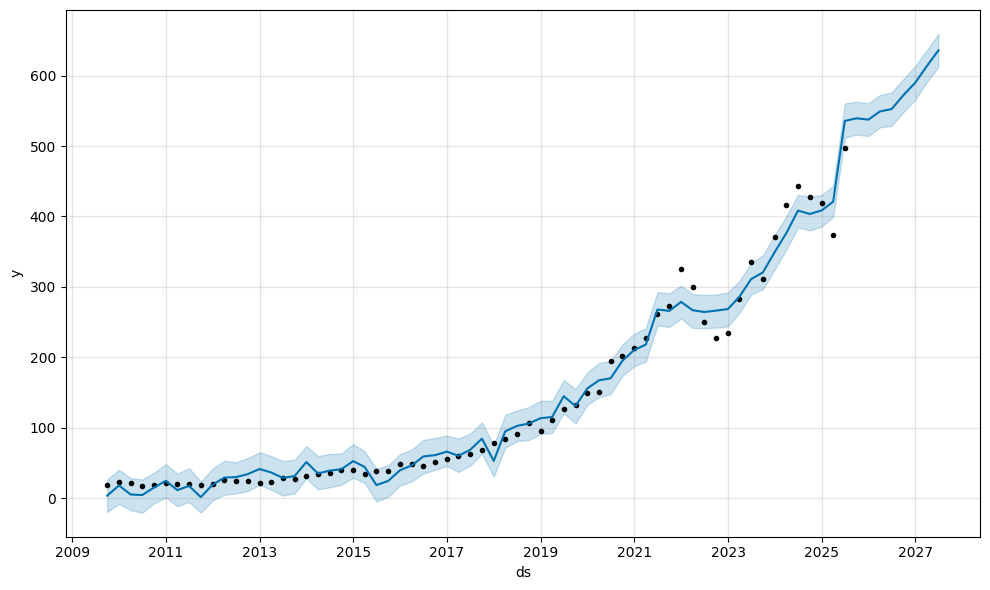

In [25]:
figl = m.plot(forecast)
figl.show()

In [26]:
correlations = data.corr()
correlations

,ds,y,revenue,net_income,ratio assets/libailities,shareholders_equity,gdp_growth,interest_rate
ds,1.000000,0.906402,0.903409,0.835994,-0.265540,0.858967,0.124506,0.732953
y,0.906402,1.000000,0.970293,0.938241,0.056362,0.956064,0.144328,0.777427
revenue,0.903409,0.970293,1.000000,0.915488,0.050396,0.952574,0.131277,0.773328
net_income,0.835994,0.938241,0.915488,1.000000,0.141435,0.906925,0.125296,0.733397
ratio assets/libailities,-0.265540,0.056362,0.050396,0.141435,1.000000,0.204939,-0.002103,0.061692
shareholders_equity,0.858967,0.956064,0.952574,0.906925,0.204939,1.000000,0.114128,0.825710
gdp_growth,0.124506,0.144328,0.131277,0.125296,-0.002103,0.114128,1.000000,0.081124
interest_rate,0.732953,0.777427,0.773328,0.733397,0.061692,0.825710,0.081124,1.000000
